# MensaFetcher — Datenexploration & Visualisierung

Dieses Notebook zeigt schnelle Beispiele, wie die Snapshots in der SQLite‑DB geladen
und zur Analyse mit `pandas` aufbereitet werden können.

Benutze `scripts.analysis_utils` für wiederverwendbare Helper‑Funktionen.

**Datenbank:** 277 Snapshots, täglich 2 Versuche (attempt 1 & 2), ~100+ Gerichte pro Snapshot.

In [45]:
# Import und Verbindung herstellen
import sys
import os
sys.path.insert(0, os.path.dirname(os.path.abspath('.')))

# Force reload of the module to pick up new functions
import importlib
if 'scripts.analysis_utils' in sys.modules:
    importlib.reload(sys.modules['scripts.analysis_utils'])

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

from scripts.analysis_utils import (
    open_conn,
    list_snapshots,
    export_snapshot_to_pandas,
    get_snapshot_entries,
    get_dish_timeseries,
    get_tags_distribution_timeseries,
)

# Pfad zur lokalen DB anpassen falls nötig
DB_PATH = '../data/mensa_260511.db'
conn = open_conn(DB_PATH)
print('✓ Connected to', DB_PATH)

✓ Connected to ../data/mensa_260511.db


## Schritt 1: Snapshots auflisten

In [4]:
# Liste alle verfügbaren Snapshots
snapshots = list_snapshots(conn)
snap_df = pd.DataFrame(snapshots)
print(f'Insgesamt {len(snapshots)} Snapshots')
print('\nErste 10:')
snap_df.head(10)

Insgesamt 277 Snapshots

Erste 10:


,id,date,attempt,created_at,empties_count,computed_at
0,1,2025-12-04,1,2025-12-04T10:15:04.411Z,0,NaN
1,2,2025-12-04,2,2025-12-04T11:45:05.147Z,2,2025-12-04T17:34:39.873663Z
2,3,2025-12-05,1,2025-12-05T10:20:04.464Z,0,NaN
3,4,2025-12-05,2,2025-12-05T13:30:05.188Z,8,2025-12-05T13:30:05.209541Z
4,5,2025-12-08,1,2025-12-08T10:20:05.525Z,0,NaN
5,6,2025-12-08,2,2025-12-08T13:30:05.681Z,10,2025-12-08T13:30:05.702927Z
6,7,2025-12-09,1,2025-12-09T10:20:05.856Z,0,NaN
7,8,2025-12-09,2,2025-12-09T13:30:05.387Z,8,2025-12-09T13:30:05.405684Z
8,9,2025-12-10,1,2025-12-10T10:20:04.701Z,0,NaN
9,10,2025-12-10,2,2025-12-10T13:30:04.908Z,6,2025-12-10T13:30:04.929842Z


## Schritt 2: Einen Snapshot als DataFrame laden

In [5]:
# Lade den ersten Snapshot als DataFrame
snapshot_id = snapshots[0]['id']
snapshot_date = snapshots[0]['date']
print(f'Lade Snapshot {snapshot_id} ({snapshot_date})')

df = export_snapshot_to_pandas(conn, snapshot_id)
print(f'✓ {len(df)} Gerichte geladen')
print('\nSpalten:', df.columns.tolist())
print('\nErste Gericht:')
df.head(2)

Lade Snapshot 1 (2025-12-04)
✓ 18 Gerichte geladen

Spalten: ['snapshot_id', 'dish_id', 'canonical_hash', 'name', 'description', 'category', 'price_eur', 'went_empty', 'tags']

Erste Gericht:


,snapshot_id,dish_id,canonical_hash,name,description,category,price_eur,went_empty,tags
0,1,4,46deda23ad042dafa8ae246ec01c389ac36c6ee7,Planted Chicken Wrap,NaN,bowl-wrap,3.2,0,"[19, WEI, HAF, 27, 1, VG, KT]"
1,1,3,d3faa252ce5efdb3e6b07992f9550ec7359db12b,Wrap mit Cevapcici und Salat,NaN,bowl-wrap,3.2,0,"[19, WEI, GER, 21, 27, 1, 8, R]"


## Schritt 3: Schnelle Statistiken

In [6]:
# Preisstatistiken
prices = df['price_eur'].dropna().astype(float)
print('PREISSTATISTIKEN:')
print(f'  Min:    €{prices.min():.2f}')
print(f'  Median: €{prices.median():.2f}')
print(f'  Mean:   €{prices.mean():.2f}')
print(f'  Max:    €{prices.max():.2f}')
print(f'  Total:  {len(prices)} Gerichte mit Preis')

# Kategorien
print('\nKATEGORIEN:')
print(df['category'].value_counts())

# Leerläufe
empties = df[df['went_empty'] == 1]
print(f'\nGERICHTE DIE LEER WAREN: {len(empties)}')

PREISSTATISTIKEN:
  Min:    €2.30
  Median: €3.20
  Mean:   €3.42
  Max:    €4.10
  Total:  18 Gerichte mit Preis

KATEGORIEN:
category
pizza-and-mehr            6
bowl-wrap                 2
campusteller              2
mensainternational        2
tagesangebot-cafeteria    2
vegetarisch               2
wok-and-grill             2
Name: count, dtype: int64

GERICHTE DIE LEER WAREN: 2


## Schritt 4: Visualisierung — Preisverteilung

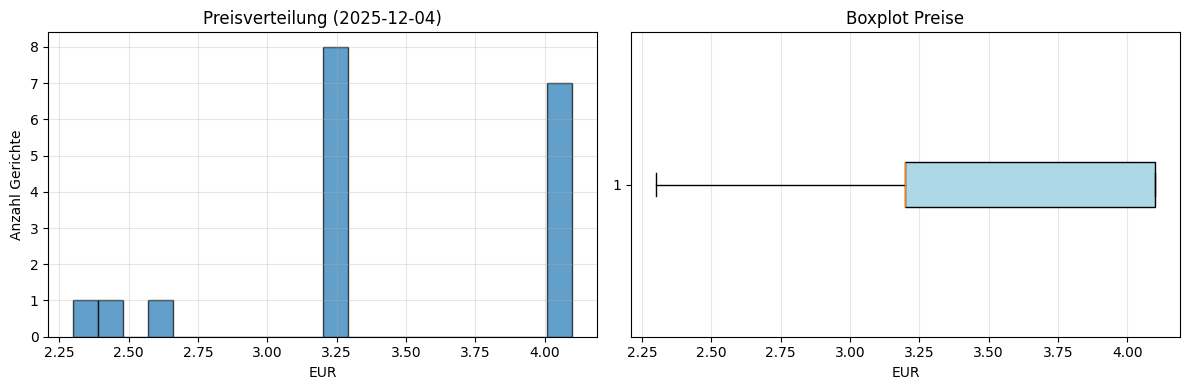

In [7]:
# Histogramm und Boxplot der Preise
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogramm
axes[0].hist(prices, bins=20, edgecolor='black', alpha=0.7)
axes[0].set_title(f'Preisverteilung ({snapshot_date})')
axes[0].set_xlabel('EUR')
axes[0].set_ylabel('Anzahl Gerichte')
axes[0].grid(True, alpha=0.3)

# Boxplot
bp = axes[1].boxplot(prices, vert=False, patch_artist=True)
bp['boxes'][0].set_facecolor('lightblue')
axes[1].set_title('Boxplot Preise')
axes[1].set_xlabel('EUR')
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

## Schritt 5: Kategorien — Durchschnittspreis

Durchschnittspreis pro Kategorie:
                         mean  median  count
category                                    
mensainternational      4.100   4.100      2
wok-and-grill           4.100   4.100      2
vegetarisch             3.650   3.650      2
pizza-and-mehr          3.350   3.200      6
bowl-wrap               3.200   3.200      2
campusteller            3.200   3.200      2
tagesangebot-cafeteria  2.515   2.515      2


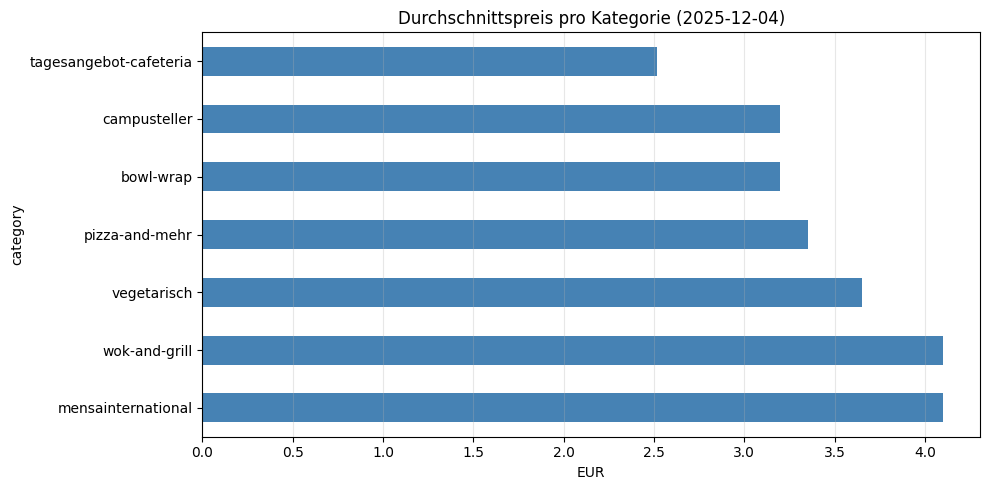

In [8]:
# Durchschnittspreis pro Kategorie
cat_prices = df.groupby('category')['price_eur'].agg(['mean', 'median', 'count']).sort_values('mean', ascending=False)
print('Durchschnittspreis pro Kategorie:')
print(cat_prices)

# Barplot
fig, ax = plt.subplots(figsize=(10, 5))
cat_prices['mean'].plot(kind='barh', ax=ax, color='steelblue')
ax.set_title(f'Durchschnittspreis pro Kategorie ({snapshot_date})')
ax.set_xlabel('EUR')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

## Schritt 6: Zeitreihen — Empties über Zeit

In [9]:
# Lade empties_count Zeitreihe aus allen Snapshots
q = "SELECT date, attempt, empties_count FROM snapshot ORDER BY date, attempt"
rows = conn.execute(q).fetchall()
ts_df = pd.DataFrame([dict(r) for r in rows])
ts_df['date'] = pd.to_datetime(ts_df['date'], errors='coerce')
ts_df = ts_df.dropna(subset=['date'])

print(f'Zeitreihe mit {len(ts_df)} Einträgen')
print(ts_df.tail())

Zeitreihe mit 277 Einträgen
          date  attempt  empties_count
272 2026-05-09        1              0
273 2026-05-09        2              0
274 2026-05-10        1              0
275 2026-05-10        2              0
276 2026-05-11        1              0


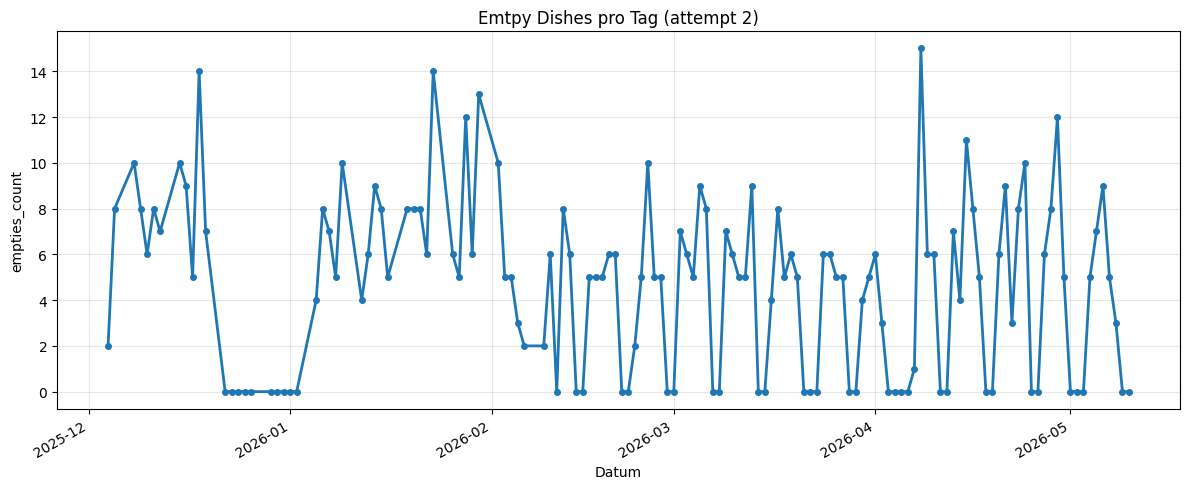


Empties Statistik (attempt 2):
  Mean: 4.6
  Max:  15
  Min:  0


In [10]:
# Plot: Empties über Zeit
fig, ax = plt.subplots(figsize=(12, 5))

# Nur attempt 2 (wo empties_count berechnet wird)
attempt2 = ts_df[ts_df['attempt'] == 2].sort_values('date')
ax.plot(attempt2['date'], attempt2['empties_count'].fillna(0).astype(int), marker='o', linestyle='-', linewidth=2, markersize=4)
ax.set_title('Emtpy Dishes pro Tag (attempt 2)')
ax.set_xlabel('Datum')
ax.set_ylabel('empties_count')
ax.grid(True, alpha=0.3)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

# Statistiken
print(f"\nEmpties Statistik (attempt 2):")
print(f"  Mean: {attempt2['empties_count'].mean():.1f}")
print(f"  Max:  {attempt2['empties_count'].max():.0f}")
print(f"  Min:  {attempt2['empties_count'].min():.0f}")

## Schritt 7: Tag‑ und Allergen‑Analyse

In [11]:
# Explodiere tags‑Spalte und zähle
if not df.empty:
    # Filtere Zeilen mit tags
    df_with_tags = df[df['tags'].apply(lambda x: len(x) > 0 if isinstance(x, list) else False)].copy()
    
    if not df_with_tags.empty:
        # Explodiere tags in einzelne Reihen
        exploded = df_with_tags.explode('tags')
        tag_counts = exploded['tags'].value_counts().head(15)
        
        print(f'Top 15 Tags/Allergene ({len(df_with_tags)} Gerichte mit tags):')
        print(tag_counts)
    else:
        print('Keine Tags im ersten Snapshot gefunden.')
        tag_counts = pd.Series(dtype=int)

Top 15 Tags/Allergene (18 Gerichte mit tags):
tags
19     15
WEI    15
24     12
1       9
5       6
26      6
27      5
6       5
S       5
21      4
V       4
R       3
G       3
HAF     2
VG      2
Name: count, dtype: int64


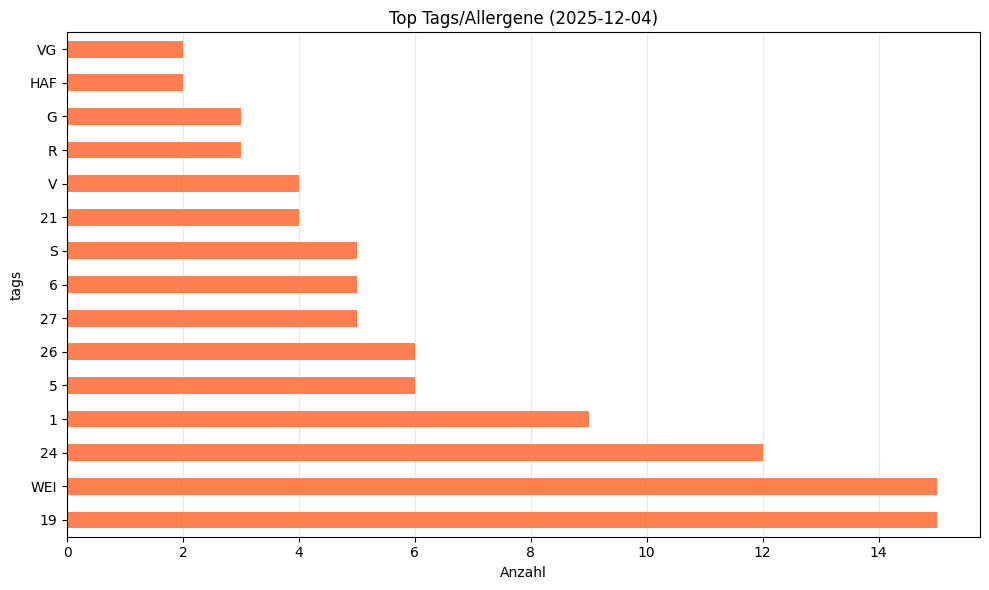

In [12]:
# Barplot: Top Tags
if not tag_counts.empty:
    fig, ax = plt.subplots(figsize=(10, 6))
    tag_counts.plot(kind='barh', ax=ax, color='coral')
    ax.set_title(f'Top Tags/Allergene ({snapshot_date})')
    ax.set_xlabel('Anzahl')
    ax.grid(True, alpha=0.3, axis='x')
    plt.tight_layout()
    plt.show()

## Schritt 8: Beispiel — Einzelnes Gericht über Zeit verfolgen

In [41]:
# Wähle ein beliebiges Gericht aus dem ersten Snapshot
if not df.empty:
    sample_dish = df.sample(1).iloc[0]
    # sample_dish = df.iloc[3]
    canonical_hash = sample_dish['canonical_hash']
    dish_name = sample_dish['name']
    print(f'Verfolge: {dish_name}')
    print(f'Hash: {canonical_hash}')
    
    # Lade Zeitreihe
    ts = get_dish_timeseries(conn, canonical_hash)
    print(f'\nGericht erschien in {len(ts)} Snapshots')
    print(ts)

Verfolge: Alaska Seelachs in Kartoffelpanade, Kräuterbutter
Hash: ec2904e7e6f636af97a05f0e4ceb911f8d79faeb

Gericht erschien in 1 Snapshots
         date  attempt  price_eur  went_empty  snapshot_id
0  2025-12-04        1        4.1           1            1


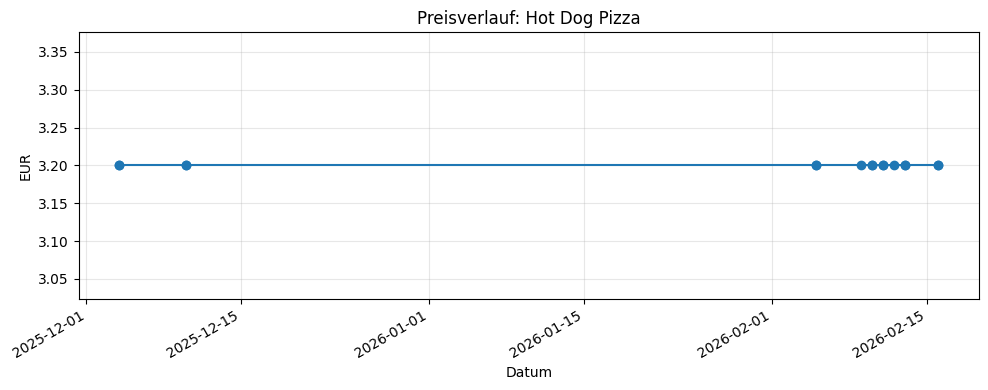

In [29]:
# Plot: Preis über Zeit für ein Gericht
if not ts.empty and 'price_eur' in ts.columns:
    fig, ax = plt.subplots(figsize=(10, 4))
    ts['date'] = pd.to_datetime(ts['date'])
    ts = ts.sort_values('date')
    
    prices_valid = ts[ts['price_eur'].notna()]
    if not prices_valid.empty:
        ax.plot(prices_valid['date'], prices_valid['price_eur'], marker='o', linestyle='-', markersize=6)
        ax.set_title(f'Preisverlauf: {dish_name}')
        ax.set_xlabel('Datum')
        ax.set_ylabel('EUR')
        ax.grid(True, alpha=0.3)
        fig.autofmt_xdate()
        plt.tight_layout()
        plt.show()

# Schritt 9: Anteile Vegetarisch, Vegan im Zeitverlauf

In [56]:
# Analysiere V/VG-Anteile über die gesamte Zeit (nur attempt 1)
# Zähle pro Tag die Anzahl Gerichte mit VG, V oder neither (über alle Gerichte)
tag_ts = get_tags_distribution_timeseries(conn, attempt=1)

if not tag_ts.empty:
    tag_ts['date'] = pd.to_datetime(tag_ts['date'])
    tag_ts = tag_ts.sort_values('date')
    
    # Explodiere tags
    tag_exploded = tag_ts.explode('tags')
    
    # Aggregate tags per dish+date and decide label (prefer VG if both)
    tag_sets = (
        tag_exploded
        .groupby(['date', 'canonical_hash'])['tags']
        .agg(lambda s: set([t for t in s if pd.notna(t)]))
        .reset_index()
    )

    def _label(ts):
        if 'VG' in ts:
            return 'VG'
        if 'V' in ts:
            return 'V'
        return 'neither'

    tag_sets['veg_label'] = tag_sets['tags'].apply(_label)

    # Zähle pro Tag die Anzahl Gerichte mit VG, V oder neither
    veg_counts = tag_sets.groupby('date')['veg_label'].value_counts().unstack(fill_value=0)

    # Sicherstellen, dass die Spalten in konsistenter Reihenfolge vorhanden sind
    for col in ['VG', 'V', 'neither']:
        if col not in veg_counts.columns:
            veg_counts[col] = 0
    veg_counts = veg_counts[['VG', 'V', 'neither']]
    print(f'\nAnzahl Gerichte mit V/VG pro Tag (attempt 1, alle Gerichte):')
    print(veg_counts)


Anzahl Gerichte mit V/VG pro Tag (attempt 1, alle Gerichte):
veg_label   VG  V  neither
date                      
2025-12-04   2  4       12
2025-12-05   1  5       13
2025-12-08   2  3       13
2025-12-09   2  3       15
2025-12-10   2  2       15
...         .. ..      ...
2026-05-07   2  5       12
2026-05-08   3  5        8
2026-05-09   0  2        5
2026-05-10   0  2        5
2026-05-11   2  5       12

[134 rows x 3 columns]


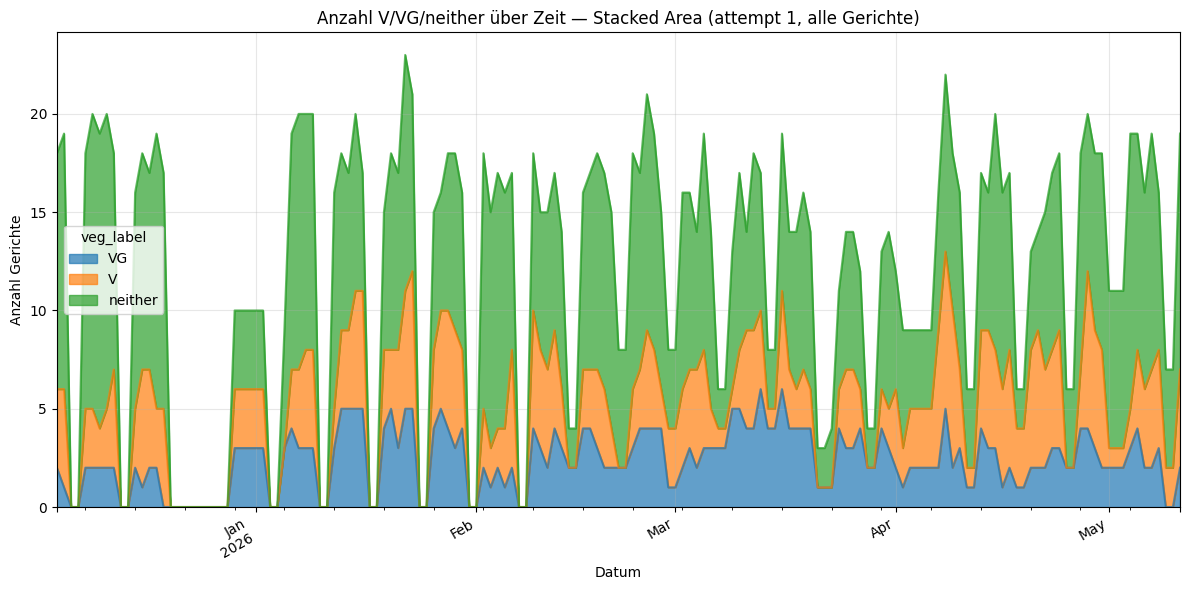

In [59]:
# Plot: Stacked Area Chart V/VG/neither über Zeit (alle Gerichte)
if not veg_counts.empty:
    # insert empty rows for missing dates to avoid misleading connections in the area plot
    veg_counts = veg_counts.asfreq('D', fill_value=0)
    fig, ax = plt.subplots(figsize=(12, 6))
    veg_counts.plot(kind='area', stacked=True, ax=ax, alpha=0.7)
    ax.set_title(f'Anzahl V/VG/neither über Zeit — Stacked Area (attempt 1, alle Gerichte)')
    ax.set_xlabel('Datum')
    ax.set_ylabel('Anzahl Gerichte')
    ax.grid(True, alpha=0.3)
    fig.autofmt_xdate()
    plt.tight_layout()
    plt.show()